   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

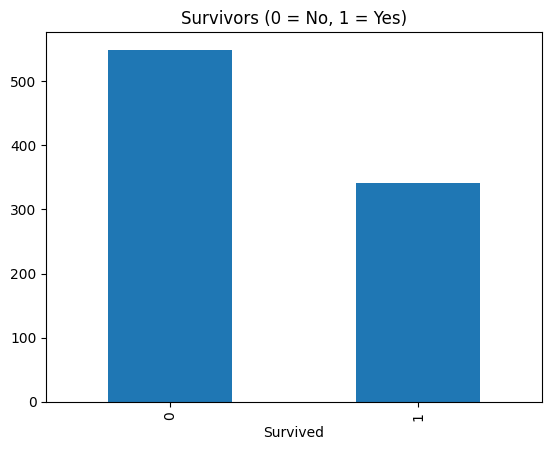

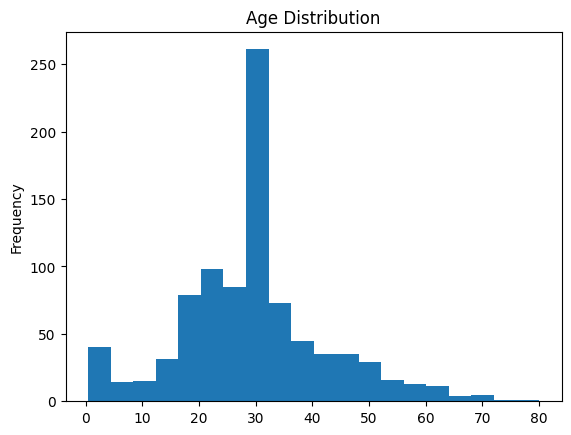

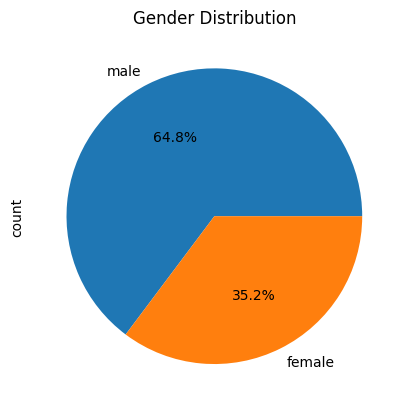

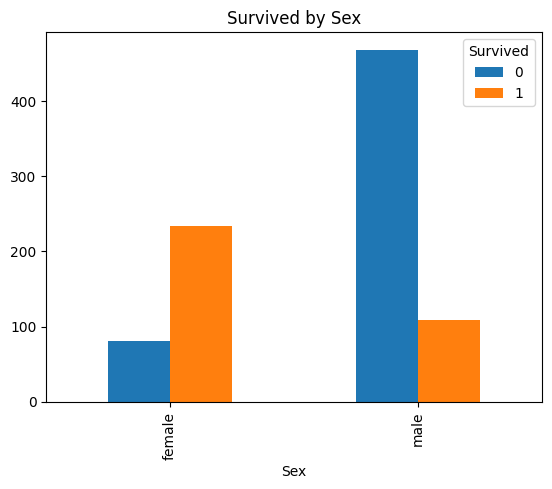

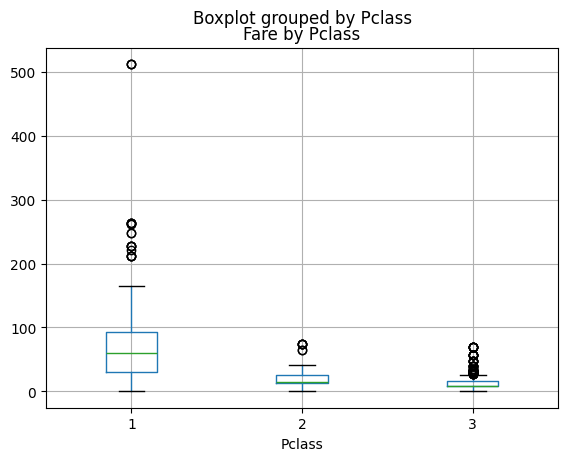

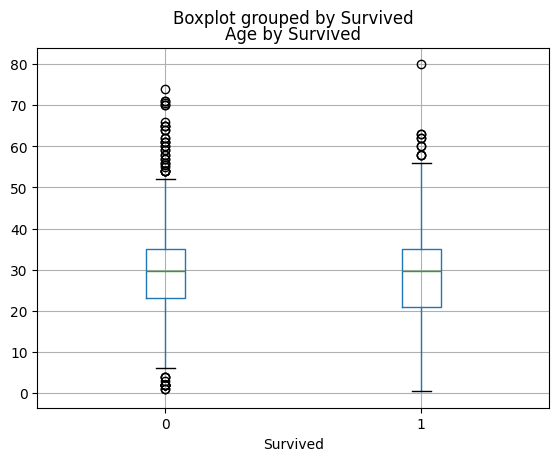

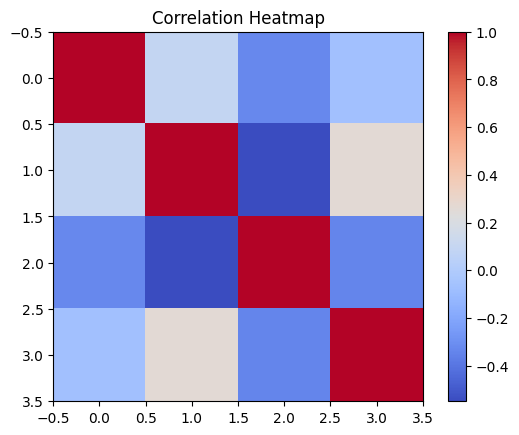

P(Survived): 0.3838383838383838
P(Female Survived): 0.7420382165605095
P(Male Survived): 0.18890814558058924
Women survived more than men.
1st class survived more than others.
Children had better survival rate.
Higher fare passengers survived more.


In [2]:
# Titanic Data Analysis with Probability

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# First 10 rows
print(df.head(10))

# Column names and data types
print(df.dtypes)

# Basic statistics
print(df.describe())

# 2) Handle Missing Values
print("Missing values before:\n", df.isnull().sum())

# Fill Age with mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill Embarked with most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing values after:\n", df.isnull().sum())

# 3) Basic Questions
print("Total passengers:", len(df))
print("Average Age:", df["Age"].mean())
print("Average Fare:", df["Fare"].mean())
print("Gender counts:\n", df["Sex"].value_counts())

# 4) Survival Analysis
print("Survived counts:\n", df["Survived"].value_counts())
print("Survival rate (%):", df["Survived"].mean()*100)

# Survival by Class
print("Survival by Pclass:\n", df.groupby("Pclass")["Survived"].mean()*100)

# Survival by Age Group
def age_group(age):
    if age <= 12:
        return "Child"
    elif age <= 19:
        return "Teen"
    elif age <= 40:
        return "Adult"
    else:
        return "Senior"

df["AgeGroup"] = df["Age"].apply(age_group)
print("Survival by AgeGroup:\n", df.groupby("AgeGroup")["Survived"].mean()*100)

# 5) Visualizations
# a) Bar chart of survivors
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survivors (0 = No, 1 = Yes)")
plt.show()

# b) Histogram of Age
df["Age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.show()

# c) Pie chart Gender
df["Sex"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

# d) Survived by Sex
df.groupby(["Sex","Survived"]).size().unstack().plot(kind="bar")
plt.title("Survived by Sex")
plt.show()

# e) Boxplot Fare by Pclass
df.boxplot(column="Fare", by="Pclass")
plt.title("Fare by Pclass")
plt.show()

# f) Violinplot Age by Survived (approx with boxplot)
df.boxplot(column="Age", by="Survived")
plt.title("Age by Survived")
plt.show()

# g) Correlation Heatmap
plt.imshow(df[["Age","Fare","Pclass","Survived"]].corr(), cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

# 6) Probability
print("P(Survived):", df["Survived"].mean())
print("P(Female Survived):", df[df["Sex"]=="female"]["Survived"].mean())
print("P(Male Survived):", df[df["Sex"]=="male"]["Survived"].mean())

# 7) Insights
print("Women survived more than men.")
print("1st class survived more than others.")
print("Children had better survival rate.")
print("Higher fare passengers survived more.")
